# FX Pairs: Exploratory Data Analysis

**Docker image**: `ml4t`

## Purpose
Profile the OANDA 20-pair, 4-hour FX dataset that anchors the FX case study. FX is OTC:
there is no central tape, so quotes and reported volumes are venue-specific, and the trading
day is a convention rather than an event. The notebook surveys coverage, quote conventions,
OHLC integrity, the gap structure of a 24/5 calendar, and the daily aggregation downstream
chapters use.

## Learning Objectives
- Load and inspect the 4-hour OHLC and indicative-volume panel for 20 pairs.
- Distinguish direct (USD-quoted), indirect (USD-base) and cross pairs.
- Read FX volume as an OANDA indicator rather than an authoritative tape.
- Recover the session grid the file is stamped on, and aggregate to daily bars on it.

## Book reference
Chapter 2, §2.2 (asset-class market data, foreign exchange). The FX case study built on this
dataset lives in `case_studies/fx_pairs/`.

## Prerequisites
- OANDA 4h FX parquet files materialized under `ML4T_DATA_PATH`.
- Loader `data.load_fx_pairs`.

In [1]:
"""FX Pairs: exploratory data analysis of OANDA currency pair data."""

import plotly.graph_objects as go
import polars as pl

from data import load_fx_pairs
from utils.data_quality import check_ohlc_invariants, per_asset_stats
from utils.style import COLORS, show_plotly_with_alt

### Declared parameters

`SESSION_TIMEZONE` and `SESSION_ROLLOVER_HOUR` are the two that carry an argument rather than
a preference. Section 5 shows that this file's bars are stamped on a grid anchored to 5PM in
New York, which is the rollover the interbank market treats as the start of a new value date,
and the daily aggregation is built on that boundary rather than on UTC midnight. Both are
declared here so the whole convention is visible in one place and CI can override it.

`MAX_PAIRS` passes straight to the loader, so a CI run can narrow the universe without any
cell downstream knowing the difference.

In [2]:
FREQUENCY = "4h"
MAX_PAIRS = 0  # 0 loads the full 20-pair universe

SESSION_TIMEZONE = "America/New_York"
SESSION_ROLLOVER_HOUR = 17  # 5PM New York starts the next value date

DEMO_PAIR = "EURUSD"
LONG_GAP_HOURS = 24  # a gap this long or longer is not an ordinary bar-to-bar step
GAP_HIST_MAX_HOURS = 80
GAP_HIST_BIN_HOURS = 2

## 1. Load and Inspect

In [3]:
fx_4h = load_fx_pairs(frequency=FREQUENCY, max_symbols=MAX_PAIRS)

print("=== FX Dataset ===")
print(f"Shape: {fx_4h.shape}")
print(f"Columns: {fx_4h.columns}")
print(f"Date range: {fx_4h['timestamp'].min()} to {fx_4h['timestamp'].max()}")

=== FX Dataset ===
Shape: (478640, 7)
Columns: ['timestamp', 'symbol', 'open', 'high', 'low', 'close', 'volume']
Date range: 2011-01-02 14:00:00 to 2025-12-31 18:00:00


### The volume column is not traded volume

FX is an OTC market with no consolidated tape, so nothing in this file can report what a
currency traded. What the column does report is narrower than that and worth naming
exactly: `data/fx/README.md` records it as **tick volume**, a count of how many times the
venue updated its quote inside the bar. It is a count of updates, not a sum of sizes.

That makes it useless for anything sized in currency and still informative about activity,
because a venue reprices when something moves. Section 2 shows how far the two come apart.

In [4]:
fx_4h.head()

timestamp,symbol,open,high,low,close,volume
datetime[ms],str,f64,f64,f64,f64,i64
2011-01-02 18:00:00,"""AUD_JPY""",83.0,83.332,82.8,82.875,986
2011-01-02 22:00:00,"""AUD_JPY""",82.877,83.015,82.698,82.796,4378
2011-01-03 02:00:00,"""AUD_JPY""",82.8,82.98,82.782,82.924,1934
2011-01-03 06:00:00,"""AUD_JPY""",82.926,83.03,82.826,83.03,3949
2011-01-03 10:00:00,"""AUD_JPY""",83.032,83.158,82.986,83.01,5296


### Symbol normalization

The file writes pairs with an underscore (`EUR_USD`). The canonical form used everywhere
downstream is concatenated (`EURUSD`), so the join keys line up.

In [5]:
fx = fx_4h.with_columns(pl.col("symbol").str.replace_all("_", "").alias("symbol"))
pairs = fx["symbol"].unique().sort().to_list()

print(f"Currency pairs ({len(pairs)}): {', '.join(pairs)}")

Currency pairs (20): AUDJPY, AUDNZD, AUDUSD, CADJPY, CHFJPY, EURAUD, EURCAD, EURCHF, EURGBP, EURJPY, EURUSD, GBPAUD, GBPCHF, GBPJPY, GBPUSD, NZDJPY, NZDUSD, USDCAD, USDCHF, USDJPY


## 2. Coverage Summary

In [6]:
pair_stats = per_asset_stats(
    fx,
    time_col="timestamp",
    asset_col="symbol",
    price_col="close",
    volume_col="volume",
)

pair_stats.sort("avg_volume", descending=True)

symbol,rows,start,end,avg_price,avg_volume
str,u32,datetime[ms],datetime[ms],f64,f64
"""GBPAUD""",23945,2011-01-02 14:00:00,2025-12-31 18:00:00,1.795271,27719.096262
"""GBPJPY""",23924,2011-01-02 18:00:00,2025-12-31 18:00:00,156.656959,22954.817673
"""EURCAD""",23921,2011-01-02 14:00:00,2025-12-31 18:00:00,1.44887,21140.860081
"""GBPCHF""",23924,2011-01-02 18:00:00,2025-12-31 18:00:00,1.302496,18534.499415
"""CHFJPY""",23919,2011-01-02 18:00:00,2025-12-31 18:00:00,122.492732,18296.437686
…,…,…,…,…,…
"""NZDUSD""",23943,2011-01-02 14:00:00,2025-12-31 18:00:00,0.702921,7312.247797
"""EURCHF""",23925,2011-01-02 14:00:00,2025-12-31 18:00:00,1.099216,6110.44698
"""EURGBP""",23922,2011-01-02 14:00:00,2025-12-31 18:00:00,0.846666,5989.497952


### The ranking is a ranking of quote updates

Ranking pairs by average tick volume puts the global majors well down the table, and the
next cell prints exactly where they land rather than leaving that as an impression.

It is tempting to read this as a liquidity ranking and it is not one. The column counts one
venue's quote updates, so the ordering reflects how often that venue repriced each pair,
and a pair can be repriced often for reasons that have nothing to do with how much of it
trades anywhere. What this file supports is the negative claim, which is the useful one: a
ranking built from this column is not a ranking of market size, and the majors sitting mid
table is the proof. Explaining *why* the ordering comes out as it does would need trade
data this file does not carry.

Rank by average indicative volume, of 20:
  USDJPY: rank 11, 13,825 per bar
  GBPUSD: rank 13, 12,212 per bar
  EURUSD: rank 14, 11,738 per bar
  top of the table: GBPAUD, 27,719 per bar


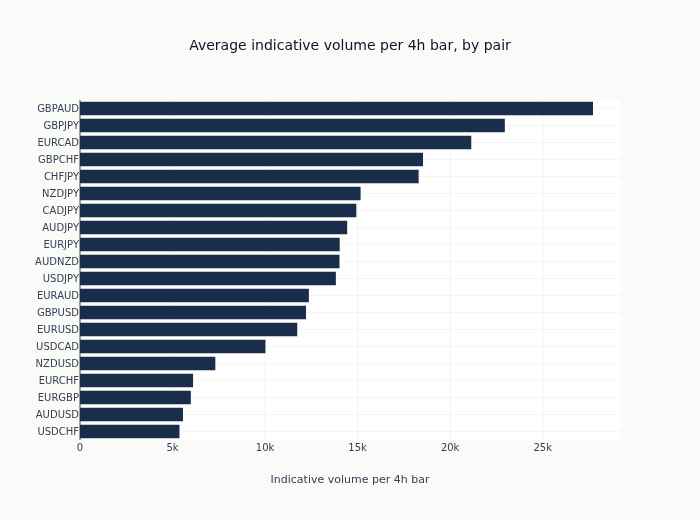

In [7]:
vol_rank = (
    fx.group_by("symbol")
    .agg(pl.col("volume").mean().alias("avg_volume"))
    .sort("avg_volume", descending=True)
    .with_row_index("rank", offset=1)
)

_majors = ["EURUSD", "USDJPY", "GBPUSD"]
print(f"Rank by average indicative volume, of {vol_rank.height}:")
for row in vol_rank.filter(pl.col("symbol").is_in(_majors)).iter_rows(named=True):
    print(f"  {row['symbol']}: rank {row['rank']}, {row['avg_volume']:,.0f} per bar")
print(f"  top of the table: {vol_rank['symbol'][0]}, {vol_rank['avg_volume'][0]:,.0f} per bar")

fig = go.Figure(
    go.Bar(
        x=vol_rank["avg_volume"].to_list(),
        y=vol_rank["symbol"].to_list(),
        orientation="h",
        marker_color=COLORS["slate"],
    )
)
fig.update_layout(
    title="Average indicative volume per 4h bar, by pair",
    xaxis_title="Indicative volume per 4h bar",
    yaxis=dict(autorange="reversed"),
    height=520,
)
show_plotly_with_alt(
    fig,
    "A horizontal bar chart of twenty currency pairs ranked by average indicative volume per "
    "four-hour bar. GBPAUD is the longest bar at roughly twenty-eight thousand and the bars "
    "shorten steadily down to USDCHF at roughly five thousand. USDJPY, GBPUSD and EURUSD sit "
    "in the lower half of the ranking rather than near the top.",
)

## 3. Quote Conventions

FX pairs follow a **BASE/QUOTE** convention: the price is the number of QUOTE units that buy
one unit of BASE. EURUSD is dollars per euro, so it falls when the dollar strengthens. USDJPY
is yen per dollar, so it rises when the dollar strengthens. EURGBP names no dollar at all.

The direction of the dollar therefore depends on where the dollar sits in the symbol, and any
composite built across pairs has to invert one group before averaging. Rather than hand-label
a subset, classify every pair by rule: *Direct* if USD is the quote currency, *Indirect* if
USD is the base, *Cross* if USD does not appear.

In [8]:
def classify_pair(sym: str) -> tuple[str, str]:
    """Classify a canonical FX symbol (e.g. 'EURUSD') by the role the dollar plays in it."""
    base, quote = sym[:3], sym[3:]
    if quote == "USD":
        return "Direct", "invert for USD strength"
    if base == "USD":
        return "Indirect", "reads as USD strength already"
    return "Cross", "no USD leg"


quote_conventions = pl.DataFrame(
    [
        {
            "symbol": p,
            "convention": classify_pair(p)[0],
            "meaning": f"{p[3:]} per {p[:3]}",
            "usd_strength": classify_pair(p)[1],
        }
        for p in pairs
    ]
).sort("convention", "symbol")

print(f"Pairs classified: {quote_conventions.height} of {len(pairs)}")
print(quote_conventions["convention"].value_counts().sort("convention"))
quote_conventions

Pairs classified: 20 of 20
shape: (3, 2)
┌────────────┬───────┐
│ convention ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ Cross      ┆ 13    │
│ Direct     ┆ 4     │
│ Indirect   ┆ 3     │
└────────────┴───────┘


symbol,convention,meaning,usd_strength
str,str,str,str
"""AUDJPY""","""Cross""","""JPY per AUD""","""no USD leg"""
"""AUDNZD""","""Cross""","""NZD per AUD""","""no USD leg"""
"""CADJPY""","""Cross""","""JPY per CAD""","""no USD leg"""
"""CHFJPY""","""Cross""","""JPY per CHF""","""no USD leg"""
"""EURAUD""","""Cross""","""AUD per EUR""","""no USD leg"""
…,…,…,…
"""GBPUSD""","""Direct""","""USD per GBP""","""invert for USD strength"""
"""NZDUSD""","""Direct""","""USD per NZD""","""invert for USD strength"""
"""USDCAD""","""Indirect""","""CAD per USD""","""reads as USD strength already"""


## 4. Data Quality

### A percentage cannot show you one bad bar

`check_ohlc_invariants` reports the share of rows satisfying each invariant. On a panel this
size a single violation moves that share by less than the display rounds away, so a column
of hundreds is consistent with a clean file and with a handful of broken bars. The count is
printed beside it, because a count of zero is a different statement from a percentage that
rounds to a hundred.

In [9]:
invariants = check_ohlc_invariants(fx)

_conditions = {
    "high_gte_low": pl.col("high") >= pl.col("low"),
    "high_gte_open": pl.col("high") >= pl.col("open"),
    "high_gte_close": pl.col("high") >= pl.col("close"),
    "low_lte_open": pl.col("low") <= pl.col("open"),
    "low_lte_close": pl.col("low") <= pl.col("close"),
    "volume_non_negative": pl.col("volume") >= 0,
}
breaches = pl.DataFrame(
    {
        "check": list(_conditions),
        "breaches": [fx.filter(~cond).height for cond in _conditions.values()],
    }
)
print(f"Rows checked: {fx.height:,}")
invariants.join(breaches, on="check", how="left")

Rows checked: 478,640


check,valid_pct,applicable_rows,total_rows,breaches
str,f64,i64,i64,i64
"""high_gte_low""",100.0,478640,478640,0
"""high_gte_open""",100.0,478640,478640,0
"""high_gte_close""",100.0,478640,478640,0
"""low_lte_open""",100.0,478640,478640,0
"""low_lte_close""",100.0,478640,478640,0
"""volume_non_negative""",100.0,478640,478640,0


### The gap between bars is the calendar

FX trades continuously from Sunday evening to Friday evening, so the interval between
consecutive bars is not always the bar length. The check runs over every pair rather than a
reference one: a gap is a property of the file, and picking the most liquid pair to test it
on samples the row least likely to show it.

Three cases are separated rather than two. A step of exactly one bar length is the ordinary
case. A Friday-to-Sunday step is the weekend close, which is the calendar working as intended
and not a hole. Everything else is neither, and the next cell shows what those turn out to be.

In [10]:
BAR_HOURS = int(FREQUENCY.rstrip("h"))

stepped = (
    fx.sort("symbol", "timestamp")
    .with_columns(
        pl.col("timestamp").diff().dt.total_hours().over("symbol").alias("gap_hours"),
        pl.col("timestamp").shift(1).over("symbol").alias("previous_timestamp"),
    )
    .drop_nulls("gap_hours")
)

_is_weekend = (pl.col("previous_timestamp").dt.weekday() == 5) & (
    pl.col("timestamp").dt.weekday() == 7
)
stepped = stepped.with_columns(
    pl.when(pl.col("gap_hours") == BAR_HOURS)
    .then(pl.lit("one bar"))
    .when(_is_weekend)
    .then(pl.lit("weekend close"))
    .otherwise(pl.lit("neither"))
    .alias("step_kind")
)

print(f"Intervals between consecutive bars: {stepped.height:,}")
print(stepped.group_by("step_kind").len().sort("len", descending=True))

Intervals between consecutive bars: 478,620
shape: (3, 2)
┌───────────────┬────────┐
│ step_kind     ┆ len    │
│ ---           ┆ ---    │
│ str           ┆ u32    │
╞═══════════════╪════════╡
│ one bar       ┆ 463116 │
│ weekend close ┆ 14456  │
│ neither       ┆ 1048   │
└───────────────┴────────┘


In [11]:
_neither = stepped.filter(pl.col("step_kind") == "neither").with_columns(
    pl.col("previous_timestamp").dt.date().alias("date"),
    pl.col("previous_timestamp").dt.strftime("%m-%d").alias("month_day"),
)
print(f"Steps that are neither one bar nor a weekend: {_neither.height:,}")

_per_date = _neither.group_by("date").agg(pl.col("symbol").n_unique().alias("pairs"))
_universe = fx["symbol"].n_unique()
_universe_wide = _per_date.filter(pl.col("pairs") == _universe)
_wide_steps = _neither.join(_universe_wide.select("date"), on="date").height
print(
    f"Distinct dates they start from: {_per_date.height}, of which "
    f"{_universe_wide.height} take out all {_universe} pairs at once. Those dates account "
    f"for {_wide_steps:,} of the {_neither.height:,} steps "
    f"({100 * _wide_steps / _neither.height:.0f}%)."
)

print("\nBy day of the year:")
print(
    _neither.group_by("month_day")
    .agg(pl.len().alias("steps"), pl.col("date").n_unique().alias("years"))
    .sort("steps", descending=True)
    .head(8)
)

Steps that are neither one bar nor a weekend: 1,048
Distinct dates they start from: 85, of which 46 take out all 20 pairs at once. Those dates account for 920 of the 1,048 steps (88%).

By day of the year:
shape: (8, 3)
┌───────────┬───────┬───────┐
│ month_day ┆ steps ┆ years │
│ ---       ┆ ---   ┆ ---   │
│ str       ┆ u32   ┆ u32   │
╞═══════════╪═══════╪═══════╡
│ 12-24     ┆ 180   ┆ 9     │
│ 12-31     ┆ 160   ┆ 8     │
│ 12-22     ┆ 40    ┆ 2     │
│ 12-23     ┆ 40    ┆ 2     │
│ 12-29     ┆ 40    ┆ 2     │
│ 02-04     ┆ 20    ┆ 1     │
│ 09-16     ┆ 20    ┆ 1     │
│ 12-03     ┆ 20    ┆ 1     │
└───────────┴───────┴───────┘


The third group is the holiday calendar. Christmas Eve and New Year's Eve dominate it, each
recurring across most years of the sample, and the days around them fill in much of the rest.

The distinction that matters is between a closure and a fault, and the pair count makes it.
Roughly half these dates take the entire universe out at once, and because those are the
recurring ones they carry the large majority of the steps. A download failure would have to
knock out twenty independently quoted instruments simultaneously and pick December 24th to
do it on. The remaining dates hit a subset of pairs and are the residue worth treating as
possible faults, which is a far smaller thing to investigate than every long gap in the file.

This is why "weekends only" is the wrong summary even though it is nearly right by count. The
leftover is small, systematic, and predictable from a calendar, and a pipeline that treats
every long gap as a weekend will read the year-end holidays as missing data every year.

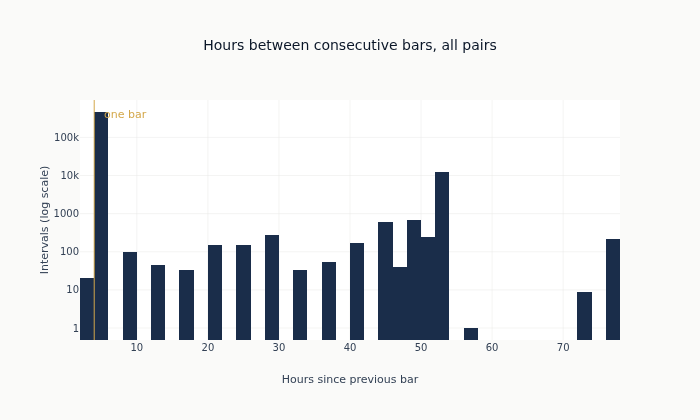

In [12]:
gap_hours = stepped.filter(pl.col("gap_hours") <= GAP_HIST_MAX_HOURS)["gap_hours"].to_list()

fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=gap_hours,
        xbins=dict(start=0, end=GAP_HIST_MAX_HOURS, size=GAP_HIST_BIN_HOURS),
        marker_color=COLORS["slate"],
    )
)
fig.add_vline(x=BAR_HOURS, line_color=COLORS["amber"], line_width=1)
fig.add_annotation(
    x=BAR_HOURS,
    y=1,
    xref="x",
    yref="paper",
    xshift=8,
    yshift=-6,
    text="one bar",
    showarrow=False,
    xanchor="left",
    yanchor="top",
    font=dict(color=COLORS["amber"]),
)
fig.update_layout(
    title="Hours between consecutive bars, all pairs",
    xaxis_title="Hours since previous bar",
    yaxis_title="Intervals (log scale)",
    yaxis_type="log",
    height=420,
)
show_plotly_with_alt(
    fig,
    "A histogram of the hours between consecutive bars, counted on a logarithmic axis. A "
    "single bar at four hours towers over everything else at more than a hundred thousand "
    "intervals. A second cluster spans roughly forty-four to fifty-four hours and peaks near "
    "twelve thousand. Between and beyond those two, isolated bars of ten to several hundred "
    "intervals appear at scattered values from eight hours out to seventy-six.",
)

## 5. The Session Grid, and Daily Aggregation On It

Aggregating to daily bars needs a day boundary, and the obvious one is UTC midnight. Before
taking it, it is worth asking what grid the timestamps are already on, because the file
answers that question directly.

In [13]:
_stamps = fx.select("timestamp").unique().sort("timestamp")
_utc_hours = sorted(_stamps.select(pl.col("timestamp").dt.hour().unique()).to_series().to_list())
_local = _stamps.with_columns(
    pl.col("timestamp")
    .dt.replace_time_zone("UTC")
    .dt.convert_time_zone(SESSION_TIMEZONE)
    .alias("local")
)
_local_hours = sorted(_local.select(pl.col("local").dt.hour().unique()).to_series().to_list())

print(f"Distinct hours-of-day the bars are stamped on, in UTC: {_utc_hours}")
print(f"Same timestamps in {SESSION_TIMEZONE}:                  {_local_hours}")

Distinct hours-of-day the bars are stamped on, in UTC: [1, 2, 5, 6, 9, 10, 13, 14, 17, 18, 21, 22]
Same timestamps in America/New_York:                  [1, 5, 9, 13, 17, 21]


Twelve hours in UTC, six in New York. The bars are not on a UTC grid at all: they are on a
six-slot local grid that includes 5PM New York, and daylight saving moves the whole grid by
an hour twice a year, which is what splits each slot into two UTC hours.

That settles the day boundary. The file is already stamped against the rollover the interbank
market uses, so a session runs from one 5PM New York to the next, and a bar printed after 5PM
counts toward the following trading day. The case study's
[`01_feasibility_analysis`](../case_studies/fx_pairs/01_feasibility_analysis.ipynb) uses a
session calendar for exactly this, declared in its `setup.yaml` as
`decision.session_calendar`.

Both aggregations are built below, because the cost of the convenient one is worth seeing.

In [14]:
sessioned = fx.with_columns(
    pl.col("timestamp")
    .dt.replace_time_zone("UTC")
    .dt.convert_time_zone(SESSION_TIMEZONE)
    .alias("local_time")
).with_columns(
    (pl.col("local_time") + pl.duration(hours=24 - SESSION_ROLLOVER_HOUR))
    .dt.date()
    .alias("session")
)

_agg = [
    pl.col("open").first(),
    pl.col("high").max(),
    pl.col("low").min(),
    pl.col("close").last(),
    pl.col("volume").sum(),
    pl.len().alias("bars"),
]

session_daily = (
    sessioned.sort("symbol", "local_time")
    .group_by("symbol", "session")
    .agg(_agg)
    .sort("symbol", "session")
)
utc_daily = (
    fx.sort("symbol", "timestamp")
    .group_by_dynamic("timestamp", every="1d", group_by="symbol")
    .agg(_agg)
)

_bars_per_day = 24 // BAR_HOURS
for label, frame in [("UTC calendar day", utc_daily), ("5PM New York session", session_daily)]:
    _full = frame.filter(pl.col("bars") == _bars_per_day).height
    print(
        f"{label:22s} {frame.height:,} daily rows, "
        f"{_full:,} of them complete ({100 * _full / frame.height:.1f}%), "
        f"{frame.filter(pl.col('bars') == 1).height:,} containing a single 4h bar"
    )

UTC calendar day       94,642 daily rows, 64,953 of them complete (68.6%), 13,886 containing a single 4h bar
5PM New York session   81,769 daily rows, 79,157 of them complete (96.8%), 1,854 containing a single 4h bar


The UTC day manufactures thousands of one-bar days. The session opens on Sunday evening in
New York, which is already Sunday night or Monday morning in UTC depending on the season, so
the UTC Sunday collects one bar and the UTC Monday collects the rest. Nothing is missing;
the boundary is simply in the wrong place, and it cuts the same session twice a week.

The two conventions also disagree about what the day closed at, on days both of them cover.

In [15]:
_compare = utc_daily.with_columns(pl.col("timestamp").dt.date().alias("day")).join(
    session_daily.rename({"session": "day"}), on=["symbol", "day"], suffix="_session"
)
_diff = (pl.col("close") - pl.col("close_session")).abs()
_differs = _compare.filter(_diff > 0)

print(f"Days both conventions cover: {_compare.height:,}")
print(
    f"  days where the close differs: {_differs.height:,} ({100 * _differs.height / _compare.height:.1f}%)"
)
print(
    "  size of that difference, in basis points: mean "
    f"{_compare.select((_diff / pl.col('close_session') * 1e4).mean()).item():.1f}, "
    f"max {_compare.select((_diff / pl.col('close_session') * 1e4).max()).item():.0f}"
)

session_daily.filter(pl.col("symbol") == DEMO_PAIR).tail(5)

Days both conventions cover: 80,886
  days where the close differs: 64,074 (79.2%)
  size of that difference, in basis points: mean 9.4, max 377


symbol,session,open,high,low,close,volume,bars
str,date,f64,f64,f64,f64,i64,u32
"""EURUSD""",2025-12-24,1.17927,1.1808,1.17726,1.1777,89168,6
"""EURUSD""",2025-12-26,1.17805,1.17968,1.17616,1.1771,120235,6
"""EURUSD""",2025-12-29,1.1768,1.17891,1.17494,1.17726,110313,6
"""EURUSD""",2025-12-30,1.1771,1.17798,1.17434,1.1748,88246,6
"""EURUSD""",2025-12-31,1.17466,1.17595,1.172,1.17459,98214,6


A daily close that is wrong by a handful of basis points on most days is not a rounding
concern. It is the whole size of a daily FX move on a quiet pair, so a label built on the UTC
close and a label built on the session close are different labels, not two estimates of one.

The general form: **an aggregation boundary is a modelling choice, and the data usually tells
you which one it was built for.** Twelve UTC hours and six local ones is the file saying so.

## Key Takeaways

1. **The volume column counts quote updates, not traded size.** The repository's own schema
   calls it tick volume, and the ranking it produces puts the global majors mid table. That
   is enough to establish what the column is not - a measure of market size - and not
   enough to explain the ordering, which would take trade data this file does not carry.

2. **The dollar's direction depends on where the dollar sits in the symbol.** Direct pairs
   quote dollars per unit and have to be inverted before entering a dollar-strength
   composite; indirect pairs already read that way; crosses have no dollar leg. Every pair is
   classified by rule above rather than a subset by hand.

3. **A share of rows passing is not a count of rows failing.** On a panel of this size one
   broken bar cannot move the reported percentage far enough to see, so the invariant table
   carries breach counts beside it.

4. **Long gaps are the calendar, and the calendar has three parts, not two.** Almost every
   step is one bar; most of the rest is the Friday-to-Sunday close; what remains is the
   holiday calendar, concentrated on the days around Christmas and New Year and hitting the
   whole universe on the same dates. Treating every long gap as a weekend misreads the
   year-end holidays as missing data, every year.

5. **The file is stamped on a New York session grid, not a UTC one.** The timestamps occupy
   twelve hours-of-day in UTC and six in New York, because daylight saving moves the grid.
   Aggregating on UTC midnight cuts each session in the wrong place, produces thousands of
   one-bar days, and disagrees with the session close on most days by an amount comparable to
   a day's move. The daily bars above are built on the 5PM New York rollover the file already
   uses and the case study declares.

**Next**: `13_data_quality_framework` profiles the cross-asset data-quality checks that
consume this panel and the others built up so far.